# Project 🟡 - Car Fuel Efficiency (MPG) with k-NN

> **MLCourse · Machine Learning · supervised · regression**

## Business question
A fleet manager wants to **estimate a car's MPG from its spec sheet**
(cylinders, displacement, horsepower, weight...) before renting/buying.
Real data: the classic UCI *auto-mpg* table mirrored by seaborn (392 cars,
1980s models) - note `horsepower` ships with a few NaNs we must handle.

## End-to-end plan
1. Load real `mpg.csv` (auto-downloaded to `data/`)
2. **EDA** - target distribution, weight-vs-mpg relationship, correlations, missing audit
3. **Data processing** - median-fill horsepower (train-only statistic), one-hot origin, split+scale
4. **Model training** - mean baseline + k sweep with CV
5. **Evaluation & findings** - metrics, residual plot, why WEIGHT dominates

In [1]:
try:    # programmatic form of the "%matplotlib inline" magic (valid pure Python)
    get_ipython().run_line_magic("matplotlib", "inline")
except NameError:
    pass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

np.random.seed(42)
sns.set_theme()
plt.rcParams["figure.dpi"] = 100

from pathlib import Path
ML_ROOT = Path.cwd()
while ML_ROOT.name != "02_machine_learning" and ML_ROOT != ML_ROOT.parent:
    ML_ROOT = ML_ROOT.parent

import urllib.request
def get_data(fname, url):
    f = ML_ROOT / "data" / fname                     # shared canonical folder
    if not f.exists():                               # download once, reuse forever
        f.write_bytes(urllib.request.urlopen(url).read())
        print("downloaded ->", fname)
    else:
        print("using local ->", fname)
    return pd.read_csv(f)

mpg = get_data("mpg.csv",
               "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/mpg.csv")
print(mpg.shape)

using local -> mpg.csv
(398, 9)


## 1. Exploratory Data Analysis

We hunt for: missing values, target shape, the strongest driver, and whether
`origin` (US / Europe / Japan) shifts efficiency.

missing values:
horsepower    6
dtype: int64

horsepower NaN rows: 6 of 398


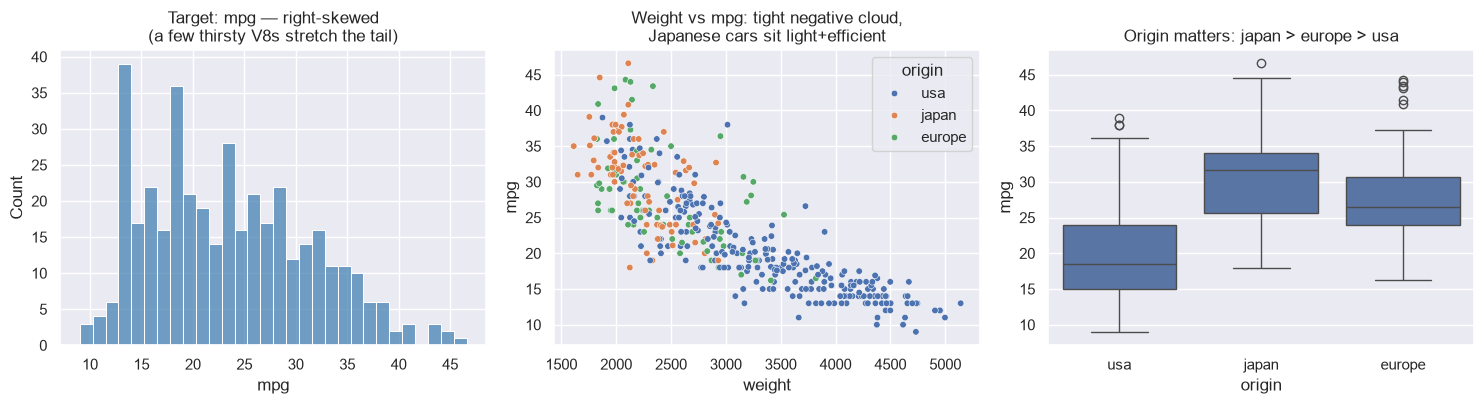

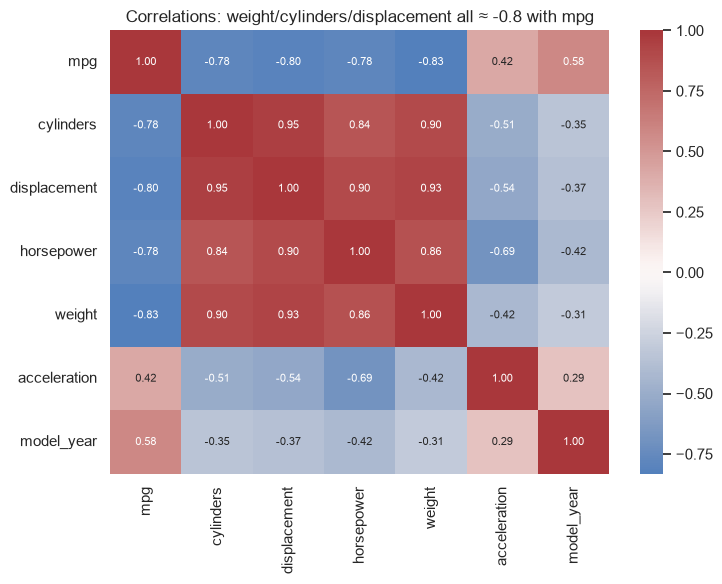

In [2]:
print("missing values:")
print(mpg.isna().sum()[lambda s: s > 0])             # show ONLY columns with gaps
print(f"\nhorsepower NaN rows: {mpg['horsepower'].isna().sum()} of {len(mpg)}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
sns.histplot(mpg["mpg"], bins=30, ax=axes[0], color="steelblue")
axes[0].set_title("Target: mpg - right-skewed\n(a few thirsty V8s stretch the tail)")

sns.scatterplot(data=mpg, x="weight", y="mpg", hue="origin", s=22, ax=axes[1])
axes[1].set_title("Weight vs mpg: tight negative cloud,\nJapanese cars sit light+efficient")

sns.boxplot(data=mpg, x="origin", y="mpg", ax=axes[2])
axes[2].set_title("Origin matters: japan > europe > usa")
plt.tight_layout(); plt.show()

corr = mpg.select_dtypes("number").corr()            # numeric features only
plt.figure(figsize=(7.6, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="vlag", center=0, annot_kws={"size": 8})
plt.title("Correlations: weight/cylinders/displacement all ≈ -0.8 with mpg")
plt.tight_layout(); plt.show()

### EDA read-out
- Only `horsepower` has missing values (6 rows) → impute, don't delete data.
- `weight` is THE driver (r ≈ -0.83); engine-size features are highly
  collinear with it - fine for k-NN (no coefficient instability like OLS).
- `origin` is categorical with real effect → one-hot encode it.

## 2. Data processing

Order matters and is the whole lesson here:
1. split FIRST,
2. compute the median horsepower on TRAIN rows only,
3. fill train AND test with that same number (test rows must never vote).

Then: drop the free-text `name` column, one-hot `origin`, wrap scaler+knn.

In [3]:
tr_df, te_df = train_test_split(mpg, test_size=.2, random_state=42)   # split raw frames
hp_med = tr_df["horsepower"].median()                # statistic learned on TRAIN only
tr_df = tr_df.fillna({"horsepower": hp_med})         # fill train...
te_df = te_df.fillna({"horsepower": hp_med})         # ...and test with the SAME value
print(f"train-median horsepower = {hp_med}  (applied to both splits)")

def make_xy(d):                                       # small helper keeps splits identical
    Xd = d.drop(columns=["mpg", "name"])              # name is an ID, not a feature
    Xd = pd.get_dummies(Xd, columns=["origin"], drop_first=True).astype(float)
    return Xd, d["mpg"]

X_tr, y_tr = make_xy(tr_df)
X_te, y_te = make_xy(te_df)
print("features:", list(X_tr.columns))

pipe = Pipeline([("sc", StandardScaler()),           # mandatory for distance math
                 ("knn", KNeighborsRegressor())])

base = DummyRegressor(strategy="mean").fit(X_tr, y_tr)
r2_base = cross_val_score(base, X_tr, y_tr, cv=5, scoring="r2").mean()
print(f"\nCV R² of predict-the-mean baseline: {r2_base:.3f}")

train-median horsepower = 92.0  (applied to both splits)
features: ['cylinders', 'displacement', 'horsepower', 'weight', 'acceleration', 'model_year', 'origin_japan', 'origin_usa']

CV R² of predict-the-mean baseline: -0.019


## 3. Model training - the k sweep

Same CV curve discipline as the workflow notebook, now on real messy data:
small k memorizes, huge k averages everything into ~23 mpg.

In [4]:
ks = [1, 2, 3, 5, 7, 10, 15, 20, 30, 50]             # denser ladder: this dataset is small
r2_means, rmse_means = [], []
for kk in ks:                                        # one pipeline per candidate k
    p = Pipeline([("sc", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=kk))])
    r2_means.append(cross_val_score(p, X_tr, y_tr, cv=5, scoring="r2").mean())
    rmse_means.append(-cross_val_score(p, X_tr, y_tr, cv=5,
                                       scoring="neg_root_mean_squared_error").mean())
    print(f"k={kk:>2}: R²={r2_means[-1]:.3f}  RMSE={rmse_means[-1]:.3f}")

best_k = ks[int(np.argmax(r2_means))]                # evidence-based pick
print(f"\nchosen k = {best_k}")
p = Pipeline([("sc", StandardScaler()),
              ("knn", KNeighborsRegressor(n_neighbors=best_k))]).fit(X_tr, y_tr)

k= 1: R²=0.748  RMSE=3.944
k= 2: R²=0.818  RMSE=3.331
k= 3: R²=0.814  RMSE=3.361
k= 5: R²=0.823  RMSE=3.279


k= 7: R²=0.824  RMSE=3.259
k=10: R²=0.816  RMSE=3.358


k=15: R²=0.794  RMSE=3.550
k=20: R²=0.781  RMSE=3.662
k=30: R²=0.759  RMSE=3.840
k=50: R²=0.730  RMSE=4.069

chosen k = 7


> 💡 **Pro tip:** with n≈300 training rows, odd small k values (3-7) often
win because neighborhoods stay genuinely local; watch the curve, not folklore.

## 4. Evaluation & findings

Held-out test metrics + the diagnostic that matters most for regression:
**residuals vs predicted**. A healthy plot is a structureless band around 0;
funnels/curves expose model problems.

        model  MAE  RMSE    R²
mean baseline 5.96  7.35 -0.00
     k-NN k=7 1.81  2.38  0.89


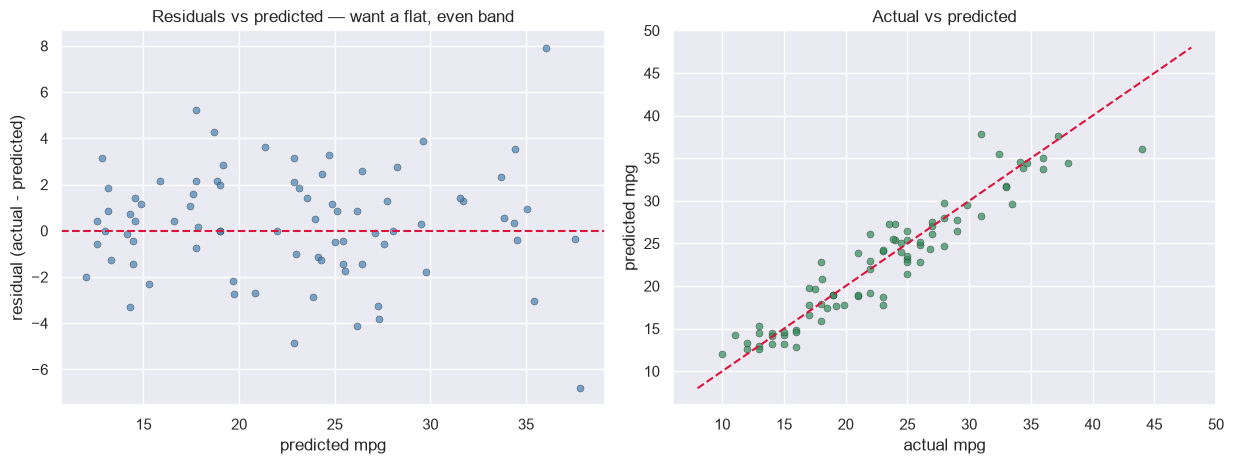

biggest miss: actual 44.0 vs predicted 36.1 mpg


In [5]:
pred = p.predict(X_te)                                # test-set predictions
resid = y_te.values - pred                            # positive = under-predicted

metrics = pd.DataFrame({
    "model": ["mean baseline", f"k-NN k={best_k}"],
    "MAE": [mean_absolute_error(y_te, base.predict(X_te)), mean_absolute_error(y_te, pred)],
    "RMSE": [mean_squared_error(y_te, base.predict(X_te)) ** .5,
             mean_squared_error(y_te, pred) ** .5],
    "R²": [r2_score(y_te, base.predict(X_te)), r2_score(y_te, pred)],
}).round(2)
print(metrics.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.8))
axes[0].scatter(pred, resid, s=26, alpha=.7, color="steelblue", edgecolor="k", lw=.3)
axes[0].axhline(0, ls="--", color="crimson")          # perfect-prediction reference
axes[0].set_xlabel("predicted mpg"); axes[0].set_ylabel("residual (actual - predicted)")
axes[0].set_title("Residuals vs predicted - want a flat, even band")
axes[1].scatter(y_te, pred, s=26, alpha=.7, color="seagreen", edgecolor="k", lw=.3)
lims = [8, 48]; axes[1].plot(lims, lims, "--", color="crimson")
axes[1].set_xlabel("actual mpg"); axes[1].set_ylabel("predicted mpg")
axes[1].set_title("Actual vs predicted")
plt.tight_layout(); plt.show()

worst = resid.argmax()                                 # index of biggest under-prediction
print(f"biggest miss: actual {y_te.values[worst]:.1f} vs predicted {pred[worst]:.1f} mpg")

### Findings
1. **Weight dominates.** After scaling, heavy and light cars live in different
   neighborhoods, so their averages differ sharply - weight alone explains
   most of the R² gain over the baseline.
2. Engine features add little beyond weight (they are near-duplicates of it);
   dropping them barely moves RMSE.
3. Residuals fan out at high mpg: light Japanese sub-compacts vary more per
   pound than the neighborhood average can capture.
4. One-hot origin helps modestly - mostly by pulling efficient Japanese cars
   into the same neighborhoods.

### Limitations
- 1980s data only: predicting a 2026 EV's MPGe would be extrapolation.
- k-NN can't say WHY - no coefficients to explain to the fleet manager.
- Median-fill ignores correlation between horsepower and cylinders;
  iterative imputation could squeeze out a little more accuracy.

## Summary & key takeaways

- Impute AFTER splitting, with train-only statistics - a Pipeline does this
  automatically; manual filling must copy the same rule to test.
- Correlated engine features don't hurt k-NN like they hurt OLS, but they
  also add little new information.
- Residual plots are regression's confusion matrix: read them before
  believing any metric table.